In [1]:
import torch

# Format versions to match PyG wheel URL scheme
torch_version = torch.__version__.split('+')[0]
cuda_version = "cu" + torch.version.cuda.replace(".", "")
whl_url = f"https://data.pyg.org/whl/torch-{torch_version}+{cuda_version}.html"

print(f"Installing PyG for PyTorch {torch_version} and {cuda_version}...")

# Install base PyG
!pip install -q torch_geometric


# Install accelerated sparse tensor extensions using the generated URL
!pip install -q pyg_lib torch_scatter torch_sparse torch_cluster -f {whl_url}

print("Installation complete. Restart your runtime.")

Installing PyG for PyTorch 2.11.0 and cu128...
Installation complete. Restart your runtime.


In [1]:

from google.colab import drive
drive.mount('/content/drive')

import sys
# Add the project to the Python path so modules can be imported
sys.path.append('/content/drive/MyDrive/Closed-Loop/fraud-redteam-project_final')

import os
# Change the working directory to the project folder
os.chdir('/content/drive/MyDrive/Closed-Loop/fraud-redteam-project_final')

!pip install -q pandas numpy scipy pyyaml matplotlib kaggle

Mounted at /content/drive


# 02 — Defend Engine Training (GBM + GNN + Sequence + Ensemble)

Trains the full Blue-team stack on one round of synthetic data from
`01_identify_and_generate.ipynb`, and validates it properly (held-out
scenario generalization, precision/recall/F1/FPR - never recall alone).

**Run 00 and 01 first.**

In [2]:
!pip install -q pandas numpy scipy pyyaml scikit-learn lightgbm networkx matplotlib

# GNN needs torch_geometric with a version matched to Colab's torch/CUDA build.
# Check your torch version first:
import torch
print("torch:", torch.__version__, "| CUDA:", torch.version.cuda)

torch: 2.11.0+cu128 | CUDA: 12.8


In [3]:
# Install torch_geometric matched to the printed torch/CUDA versions above.
# Example for torch 2.3.0 + CUDA 12.1 (ADJUST to match your printed versions):
TORCH_VERSION = "2.3.0"
CUDA_VERSION = "cu121"  # or "cpu" if no GPU

!pip install -q torch_geometric
!pip install -q pyg_lib torch_scatter torch_sparse -f https://data.pyg.org/whl/torch-{TORCH_VERSION}+{CUDA_VERSION}.html
!pip install -q faker

# If this cell fails, the pipeline still runs - gnn_model.py and sequence_model.py
# both fall back to a CPU-only non-torch path automatically (see their docstrings).
# You can skip this cell entirely for a first pass and come back to it once the
# rest of the pipeline is validated.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 82.3 MB/s eta 0:00:00


In [4]:
!pip install -q -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 51.5 MB/s eta 0:00:00


In [5]:
import sys
sys.path.insert(0, ".")

import pandas as pd
from src.generate.orchestrator import GenerateOrchestrator
from src.identify.coverage_matrix import CoverageMatrix

# reuse the round generated in notebook 01, or generate a fresh one here for testing
coverage = CoverageMatrix(path="data/coverage_matrix.csv")
scenarios = coverage.as_scenario_dicts()
for i, s in enumerate(scenarios):
    s["scenario_id"] = f"nb02_{i}"

print(f"Loaded {len(scenarios)} scenarios from coverage matrix.")
for s in scenarios:
    print(" -", s["scenario_name"], f"({s['manipulation_type']})")

Loaded 42 scenarios from coverage matrix.
 - Nullified Device Fingerprint Velocity Pacing (behavioral)
 - Synthetic Identity Low-Velocity Micro-Dispersal (identity)
 - Nullified-Fingerprint P2M Velocity Evasion (behavioral)
 - Deepfake Video-KYC Teleportation Burst (ai_specific)
 - Sybil Refund Loop via High-Risk Email Identity Mesh (identity)
 - Automated Micro-Probe Card Authorization Sweeps (behavioral)
 - Aged Account Collusive Friendly Fraud Swarm (behavioral)
 - Rapid Cascading Fan-In Mule Smurf Chain (network)
 - Geocode-Shifted Merchant Promo Exploitation Swarm (channel)
 - Distributed Credential-Stuffing ATO P2P Drain (behavioral)
 - Social-Engineered Dormant Mule Phase Shift (behavioral)
 - Oscillating Emulator Geocode-OS Drift (behavioral)
 - Contextual LLM Collect-Request Target Swarm (ai_specific)
 - Collusive Merchant Interspersed Fake-Invoice Cashout (network)
 - Nullified-Device Headless Multi-Payer Split-Payment Evasion (channel)
 - Incremental KYC Similarity Amplifica

In [6]:
_orch = GenerateOrchestrator()
raw_df = _orch.run_round(
    scenarios=scenarios,
    n_legit_accounts=800,
    fraud_txns_per_scenario_range=(15, 30),
    round_n=1,
    out_dir="data/generated",
)
print(raw_df.shape)

[round 1] 7198 txns (839 fraud, 11.656%) -> saved to data/generated/round_01
(7198, 34)


## Train the full Defend bundle (GBM -> GNN -> Sequence -> Ensemble)

In [7]:
from src.defend.train import train_defend_bundle, per_scenario_metrics

bundle = train_defend_bundle(raw_df)

print("=== Metrics ===")
for k, v in bundle.metrics.items():
    print(f"{k}: {v}")

/usr/local/lib/python3.13/dist-packages/torch_geometric/utils/convert.py:278: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  data_dict[key] = torch.as_tensor(value)


=== Metrics ===
gbm_val_auc: 0.7104835841569332
gnn_val_auc: 0.7631920549544738
gnn_backend: torch_geometric
sequence_val_auc: 0.8794827521955703
sequence_backend: lstm_torch
ensemble_auc: 0.8450209279837817
ensemble_precision: 0.5065075921908894
ensemble_recall: 0.5566150178784267
ensemble_f1: 0.5303804656445201
ensemble_fpr: 0.0715521308381821
ensemble_weights: {'gbm_score': 9.338698206246312, 'gnn_score': -0.8486406329529134, 'sequence_score': 5.00930945597451, 'kyc_doc_similarity_score': 5.20362786527739, 'amount_zscore_vs_self': -1.8446113348029015e-08, 'graph_shared_device_count': 0.25330771488837034, 'has_dynamic_refurl': 0.0, 'null_device_x_velocity': -0.02996515423872774, 'kyc_borderline_risk': 0.0}


## Critical checkpoint — held-out scenario generalization

Per the requirements doc's own flagged pitfall: don't let the model
overfit to injector artifacts. Hold out ONE scenario type entirely from
training and check its recall separately.

In [8]:
held_out_scenario = scenarios[0]["scenario_name"]
print(f"Holding out: {held_out_scenario}")

train_df = raw_df[
    (raw_df["scenario_name"] != held_out_scenario) | (raw_df["is_fraud"] == False)
].copy()

held_out_bundle = train_defend_bundle(train_df)

held_out_txns = raw_df[raw_df["scenario_name"] == held_out_scenario]
held_out_feat = held_out_bundle.feature_assembler.assemble(held_out_txns)

held_out_feat["gbm_score"] = held_out_bundle.gbm.score(held_out_feat)

account_ids = held_out_feat["account_id"].dropna().unique().tolist()
gnn_scores = held_out_bundle.gnn.score(held_out_bundle.feature_assembler.graph, account_ids)
held_out_feat["gnn_score"] = held_out_feat["account_id"].map(gnn_scores).fillna(0.0)

from src.defend.sequence_model import build_account_sequences
seq_scores = held_out_bundle.sequence.score(build_account_sequences(held_out_feat))
held_out_feat["sequence_score"] = held_out_feat["account_id"].map(seq_scores).fillna(0.0)

from src.defend.ensemble import RAW_SIGNAL_COLUMNS
for col in RAW_SIGNAL_COLUMNS:
    if col not in held_out_feat.columns:
        held_out_feat[col] = 0.0

attribution = held_out_bundle.ensemble.score_with_attribution(held_out_feat)
held_out_feat["final_score"] = attribution["final_score"]
held_out_feat["flagged"] = attribution["flagged"]
held_out_feat["caught_by_model"] = (held_out_feat["flagged"] == 1) & (held_out_feat["is_fraud"] == True)

n_fraud = int(held_out_feat["is_fraud"].sum())
n_caught = int(held_out_feat["caught_by_model"].sum())
print(f"{held_out_scenario}: {n_caught}/{n_fraud} caught ({n_caught/max(n_fraud,1):.1%}) "
      f"despite zero training exposure to this scenario type")

Holding out: Nullified Device Fingerprint Velocity Pacing
Nullified Device Fingerprint Velocity Pacing: 17/17 caught (100.0%) despite zero training exposure to this scenario type


## Per-scenario detection breakdown (never report one blended number)

In [9]:
scenario_metrics = per_scenario_metrics(bundle.scored_df)
scenario_metrics.sort_values("detection_rate")

,scenario_name,n_txns,n_caught,detection_rate
9,Contextual LLM Collect-Request Target Swarm,16,5,0.312500
33,Rotating Device Fingerprint Low-Volume MCC Spread,19,6,0.315789
20,MCC Spoofing Aggregated Drift Swarm,18,6,0.333333
17,Geocode-Shifted Merchant Promo Exploitation Swarm,29,10,0.344828
7,Compromised Device IP Amplification Swarm,20,7,0.350000
0,AI-Voice Phish Referral Chain Cash-Out,23,9,0.391304
8,Compromised Device IP Amplification Swarm via ...,20,8,0.400000
32,RefUrl Token Relay with Rotating Compromised IPs,17,7,0.411765
6,Collusive Merchant Interspersed Fake-Invoice C...,29,12,0.413793
21,Null Device Fingerprint Geo-Shift Swarm,29,12,0.413793


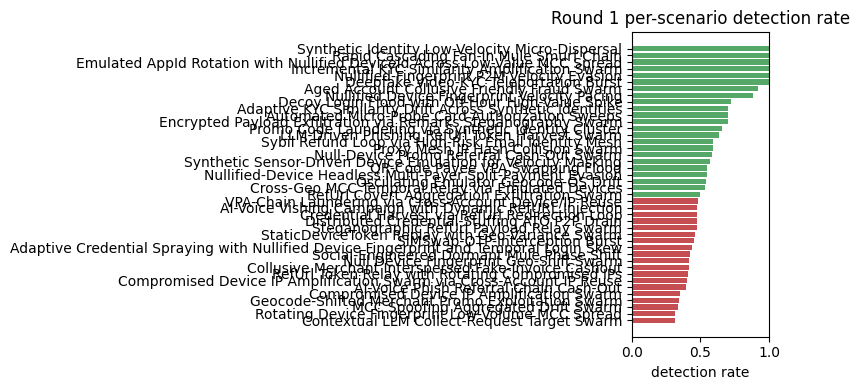

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#C44E52" if v < 0.5 else "#55A868" for v in scenario_metrics.sort_values("detection_rate")["detection_rate"]]
ax.barh(scenario_metrics.sort_values("detection_rate")["scenario_name"],
        scenario_metrics.sort_values("detection_rate")["detection_rate"], color=colors)
ax.set_xlabel("detection rate")
ax.set_xlim(0, 1)
ax.set_title("Round 1 per-scenario detection rate")
plt.tight_layout()
plt.show()

## Precision/Recall/F1/FPR - report all four, never recall alone

In [12]:
print(f"Precision: {bundle.metrics['ensemble_precision']:.3f}")
print(f"Recall:    {bundle.metrics['ensemble_recall']:.3f}")
print(f"F1:        {bundle.metrics['ensemble_f1']:.3f}")
print(f"FPR:       {bundle.metrics['ensemble_fpr']:.3f}  <- a 99% recall model with high FPR is useless")
print(f"\nEnsemble subsystem weights (explainability): {bundle.metrics['ensemble_weights']}")

Precision: 0.507
Recall:    0.557
F1:        0.530
FPR:       0.072  <- a 99% recall model with high FPR is useless

Ensemble subsystem weights (explainability): {'gbm_score': 9.338698206246312, 'gnn_score': -0.8486406329529134, 'sequence_score': 5.00930945597451, 'kyc_doc_similarity_score': 5.20362786527739, 'amount_zscore_vs_self': -1.8446113348029015e-08, 'graph_shared_device_count': 0.25330771488837034, 'has_dynamic_refurl': 0.0, 'null_device_x_velocity': -0.02996515423872774, 'kyc_borderline_risk': 0.0}


In [13]:
import pandas as pd
cov = pd.read_csv("data/coverage_matrix.csv")
print(cov.shape)
print(cov["round_added"].value_counts())  # see how it grew — helps you decide fast vs clean

(42, 13)
round_added
0    24
1     6
2     6
3     6
Name: count, dtype: int64


In [14]:
import shutil, os

# backup first, always
shutil.copy("data/coverage_matrix.csv", "data/coverage_matrix_backup_42.csv")

# wipe it so 03 starts from zero — it doesn't need 01/02 to have run first anyway
os.remove("data/coverage_matrix.csv")